# Performance of ML models in extrapolation

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

In [12]:
# Make the dataset
N = 1000
X = np.random.random((N, 2)) * 6 - 3 # uniformly distributed between (-3, +3)
Y = np.cos(2*X[:,0]) + np.cos(3*X[:,1]) # cos(2x_1)+cos(3x_2)

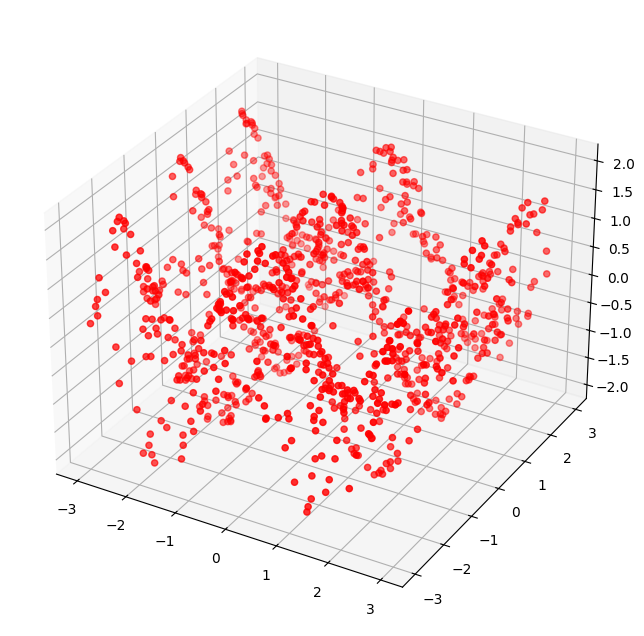

In [61]:
# Plot it
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y, c='red')
plt.show()

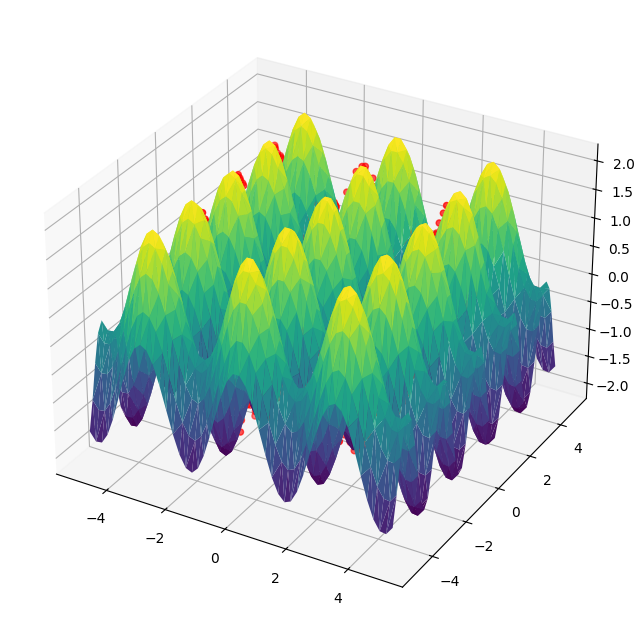

In [50]:
# What the true function looks like
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y,c='r')

# surface plot
line = np.linspace(-5, 5, 50)
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Ytrue = np.cos(2*Xgrid[:,0]) + np.cos(3*Xgrid[:,1]) ### the true function
ax.plot_trisurf(Xgrid[:,0], Xgrid[:,1], Ytrue, linewidth=0.2, antialiased=True, cmap='viridis')
plt.show()

In [77]:
# SVR
model = SVR(C=100.)
model.fit(X, Y)

SVR(C=100.0)

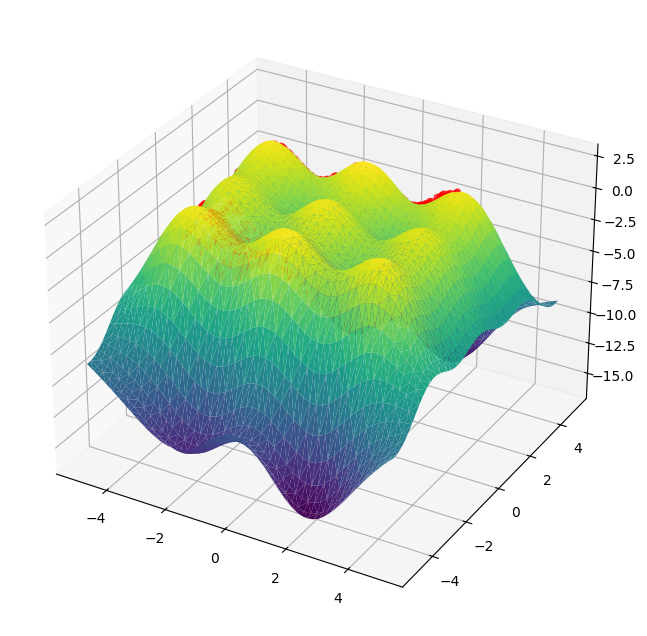

In [78]:
# Can it extrapolate?
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y, c='red')

# surface plot
line = np.linspace(-5, 5, 50)
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Yhat = model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0], Xgrid[:,1], Yhat, linewidth=0.2, antialiased=True, cmap='viridis')
plt.show()

SVR does not extrapolate well.

In [75]:
model = RandomForestRegressor()
model.fit(X, Y)

RandomForestRegressor()

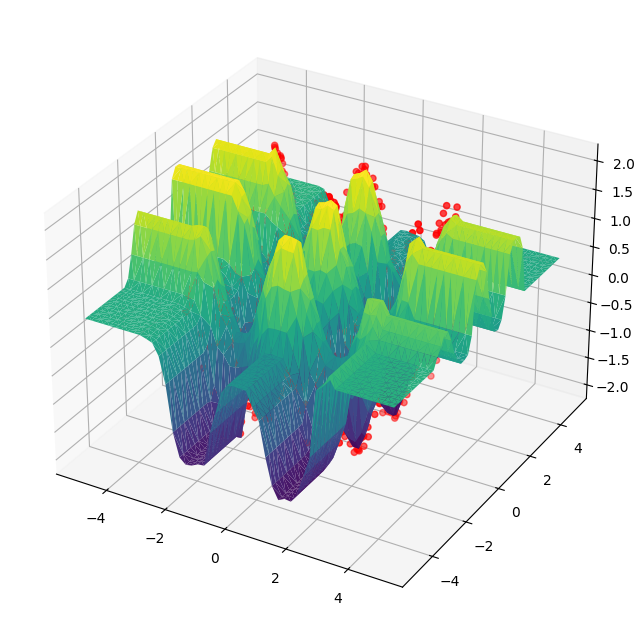

In [76]:
# Can it extrapolate?
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y, c='red')

# surface plot
line = np.linspace(-5, 5, 50)
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Yhat = model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0], Xgrid[:,1], Yhat, linewidth=0.2, antialiased=True, cmap='viridis')
plt.show()

There are no more decision splits beyond the training values. Random Forest Regressor does not extrapolate well.

In [57]:
model = MLPRegressor(hidden_layer_sizes=128, alpha=0., learning_rate_init=0.01) # Multi-layer Perceptron regressor: neural network
model.fit(X, Y)

MLPRegressor(alpha=0.0, hidden_layer_sizes=128, learning_rate_init=0.01)

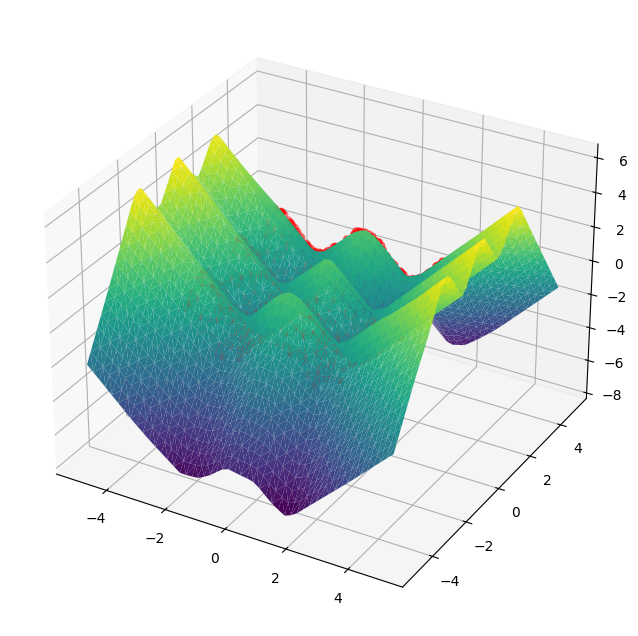

In [74]:
# Can it extrapolate?
fig = plt.figure(figsize=(20,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0], X[:,1], Y, c='red')

# surface plot
line = np.linspace(-5, 5, 50)
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Yhat = model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0], Xgrid[:,1], Yhat, linewidth=0.2, antialiased=True, cmap='viridis')
plt.show()

MLPRegressor does not extrapolate well.

## Observation: ML models extraploate poorly.

# Forecasting Stock Prices and Extrapolation

In [81]:
!wget -nc https://lazyprogrammer.me/course_files/SPY.csv

--2025-04-06 22:16:36--  https://lazyprogrammer.me/course_files/SPY.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 2606:4700:3030::ac43:d5a6, 2606:4700:3031::6815:17d2, 172.67.213.166, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|2606:4700:3030::ac43:d5a6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 251935 (246K) [text/csv]
Saving to: ‘SPY.csv’

SPY.csv             100%[===================>] 246.03K  --.-KB/s    in 0.02s   

2025-04-06 22:16:37 (9.75 MB/s) - ‘SPY.csv’ saved [251935/251935]



In [83]:
import pandas as pd

In [84]:
df = pd.read_csv('SPY.csv', index_col='Date', parse_dates=True)

In [90]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [91]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,112.370003,113.389999,111.510002,113.330002,92.246048,118944600
2010-01-05,113.260002,113.680000,112.849998,113.629997,92.490204,111579900
2010-01-06,113.519997,113.989998,113.430000,113.709999,92.555328,116074400
2010-01-07,113.500000,114.330002,113.180000,114.190002,92.946060,131091100
2010-01-08,113.889999,114.620003,113.660004,114.570000,93.255348,126402800


In [92]:
df.shape

(2263, 6)

In [130]:
train = df.iloc[:2000]['Close'].to_numpy()
test = df.iloc[2000:]['Close'].to_numpy()

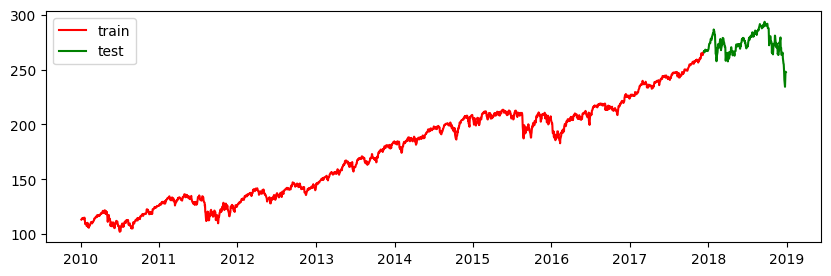

In [132]:
plt.figure(figsize=(10, 3))
plt.plot(df['Close'].iloc[:2000],c='red',label='train')
plt.plot(df['Close'].iloc[2000:],c='green',label='test')
plt.legend()
plt.show()

Stock prices tend to follow a trend. The testing prices are out of range of training prices.

In [135]:
# prepare data X to build autoregressive model with two lags (2 for visualization purpose later)
Xtrain = []
for t in range(len(train) - 1):
  x0 = train[t]
  x1 = train[t + 1]
  Xtrain.append((x0, x1))

Xtest = []
for t in range(len(test) - 1):
  x0 = test[t]
  x1 = test[t + 1]
  Xtest.append((x0, x1))

In [134]:
Xtrain = np.array(Xtrain)
Xtest = np.array(Xtest)

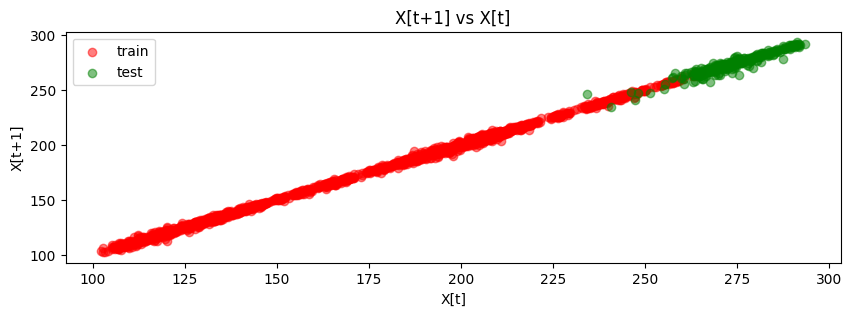

In [116]:
plt.figure(figsize=(10, 3))
plt.xlabel("X[t]")
plt.ylabel("X[t+1]")
plt.title("X[t+1] vs X[t]")
plt.scatter(Xtrain[:,0], Xtrain[:,1], c='r', alpha=0.5, label='train')
plt.scatter(Xtest[:,0], Xtest[:,1], c='g', alpha=0.5, label='test')
plt.legend()
plt.show()

Xtest is indeed out of range of Xtrain.

## Observation: Forecasting stock prices may lead to extrapolation, which is not ideal for the performance of ML algorithms.